In [ ]:
import pandas as pd

cols_to_convert = [
    'Average journey time', 
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

def convert_to_type(df, columns):
    for col in columns:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace(',', '.')
        df[col] = df[col].str.replace(' min', '')
        df[col] = df[col].str.replace('%', '')
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

#convert_to_type: take the dataset and change the type of all the columns in "cols_to_convert" to a numerics type (and delete extra unsed string like min and % in the data)

def read_csv(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=";")
    df = convert_to_type(df, cols_to_convert)
    df = df.drop_duplicates()
    df = df.fillna(value=0)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
    df['Date'] = df['Date'].dt.to_period('M')
    return df

filepath = "dataset.csv"
output_file = "cleaned_dataset.csv"

df = read_csv(filepath)
df.to_csv(output_file, index=False)

df.info()

<class 'pandas.DataFrame'>
Index: 11896 entries, 0 to 12060
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype    
---  ------                                                                         --------------  -----    
 0   Date                                                                           11516 non-null  period[M]
 1   Service                                                                        11896 non-null  object   
 2   Departure station                                                              11896 non-null  object   
 3   Arrival station                                                                11896 non-null  object   
 4   Average journey time                                                           11896 non-null  float64  
 5   Number of scheduled trains                                                     11896 non-null  float64  
 6   Number of cancelled tr

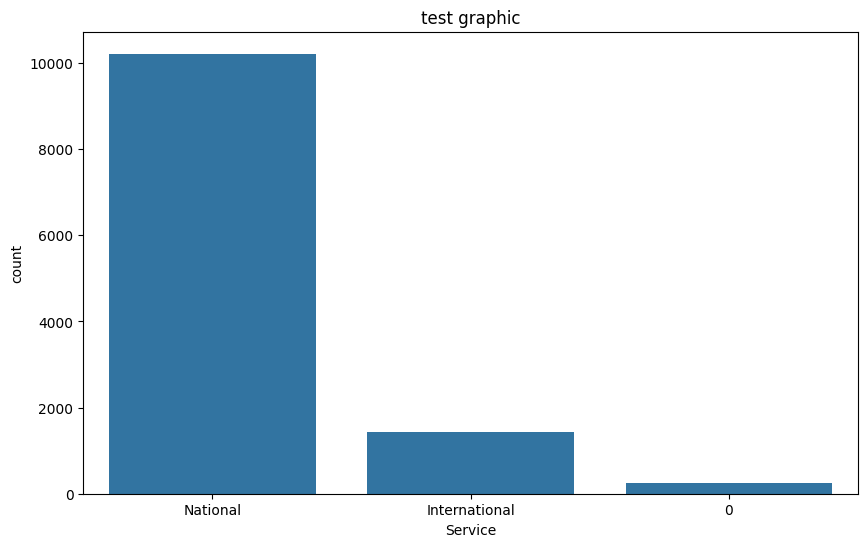

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Service')
plt.title("test graphic")
plt.show()

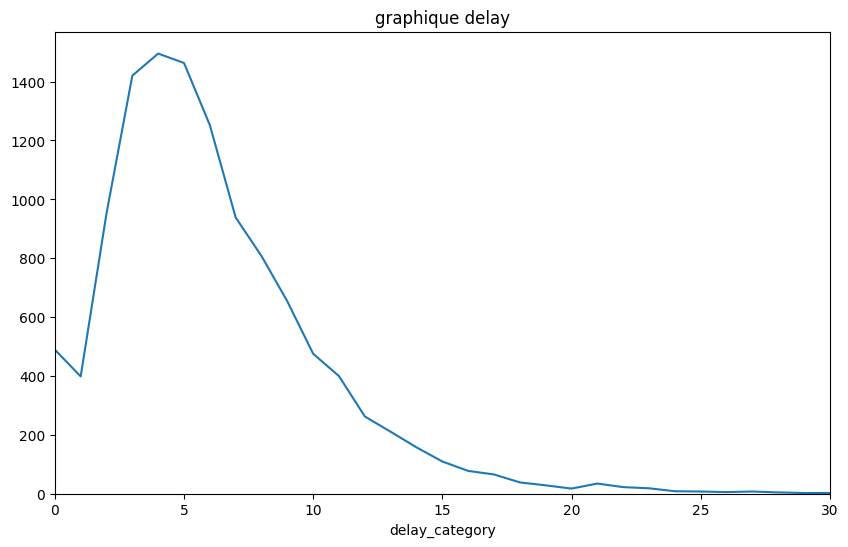

In [12]:
df['delay_category'] = pd.to_numeric(df['Average delay of all trains at arrival'], errors='coerce').round()
counts = df['delay_category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
plt.xlim(0, 30)
plt.ylim(0)
plt.title("graphique delay")
plt.show()